# Solar Wind & Dst — EDA on Enriched Dataset

**Source:** `DATA/enriched.parquet` (output of `training/prepare_data.py`)

This notebook does full EDA on the already-merged, already-enriched dataset.
No raw CSV loading, no manual merging — everything is ready.

**Sections:**
1. Load & Overview
2. Period Comparison (train_a / train_b / train_c)
3. Dst Distribution & Storm Statistics
4. Burton ODE vs Actual Dst
5. Residual Analysis (what Agent 3 must learn)
6. Feature Correlations
7. Rolling Features vs Dst
8. Storm Phase Analysis
9. Storm Weight Distribution
10. Lag Cross-Correlation Analysis *(optimal SEQ_LEN)*
11. Burton Failure Case Studies *(where physics fails)*
12. ACE vs DSCOVR Satellite Comparison
13. Residual Autocorrelation (ACF / PACF) *(validates LSTM)*
14. Solar Cycle Effect *(sunspot number vs storm activity)*
15. Feature Distributions — All 14 LSTM Input Features
16. LSTM Input Sequence Visualization *(what the model actually sees)*
17. Train/Val Split Strategy

## 1. Imports & Load

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('../DATA/enriched.parquet')

print('Loading enriched.parquet...')
df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Periods: {df["period"].unique()}')
df.head(3)

Loading enriched.parquet...
Shape: (8392320, 25)
Columns: ['bz_gsm', 'by_gsm', 'bt', 'speed', 'density', 'temperature', 'E_field', 'Q', 'dst_burton', 'dDst_dt', 'rolling_error_3h', 'bz_gsm_mean_1h', 'bz_gsm_std_3h', 'speed_mean_3h', 'E_field_mean_6h', 'smoothed_ssn', 'source_encoded', 'storm_phase', 'storm_weight', 'gse_x_ace', 'gse_y_ace', 'dst', 'residual', 'period', 'timedelta']
Periods: ['train_a' 'train_b' 'train_c']


,bz_gsm,by_gsm,bt,speed,density,temperature,E_field,Q,dst_burton,dDst_dt,...,smoothed_ssn,source_encoded,storm_phase,storm_weight,gse_x_ace,gse_y_ace,dst,residual,period,timedelta
0,1.25,3.00,6.80,383.92,1.53,110237.0,-0.479900,0.0,0.0,0.0,...,65.4,0,0,1.0,1522376.9,143704.6,-7,-7.0,train_a,0 days 00:00:00
1,2.88,-2.19,6.43,387.04,8.20,36068.0,-1.114675,0.0,0.0,0.0,...,65.4,0,0,1.0,1522376.9,143704.6,2,NaN,train_a,0 days 11:59:00
2,1.17,3.16,6.83,381.79,1.69,123825.0,-0.446694,0.0,0.0,0.0,...,65.4,0,0,1.0,1522376.9,143704.6,-7,NaN,train_a,0 days 00:01:00


## 2. Period Comparison

In [12]:
print('=== Period Overview ===')
for p in df['period'].unique():
    sub = df[df['period'] == p]
    days = sub['timedelta'].max().days
    dst_vals = sub['dst'].dropna()
    print(f'\n{p}:')
    print(f'  Rows:          {len(sub):,}')
    print(f'  Duration:      {days} days ({days/365.25:.1f} years)')
    print(f'  Dst min:       {dst_vals.min():.0f} nT')
    print(f'  Dst mean:      {dst_vals.mean():.1f} nT')
    print(f'  Storms (<-30): {(dst_vals < -30).sum():,} hours')
    print(f'  Extreme (<-100):{(dst_vals < -100).sum():,} hours')
    print(f'  Burton RMSE:   {np.sqrt((sub["residual"].dropna()**2).mean()):.2f} nT')

=== Period Overview ===

train_a:
  Rows:          1,729,440
  Duration:      1200 days (3.3 years)
  Dst min:       -387 nT
  Dst mean:      -16.6 nT
  Storms (<-30): 334,800 hours
  Extreme (<-100):25,800 hours
  Burton RMSE:   21.69 nT

train_b:
  Rows:          3,155,040
  Duration:      2190 days (6.0 years)
  Dst min:       -223 nT
  Dst mean:      -9.7 nT
  Storms (<-30): 277,140 hours
  Extreme (<-100):6,000 hours
  Burton RMSE:   10.79 nT

train_c:
  Rows:          3,507,840
  Duration:      2435 days (6.7 years)
  Dst min:       -374 nT
  Dst mean:      -9.6 nT
  Storms (<-30): 243,180 hours
  Extreme (<-100):11,040 hours
  Burton RMSE:   12.69 nT


## 3. Dst Distribution & Storm Statistics

=== Dst Storm Classification ===
  Quiet (>-30)                  : 7,475,640 (89.1%)
  Minor (-30 to -50)            : 639,420 (7.6%)
  Moderate (-50 to -100)        : 233,520 (2.8%)
  Intense (-100 to -200)        : 39,000 (0.5%)
  Extreme (<-200)               :  4,740 (0.1%)


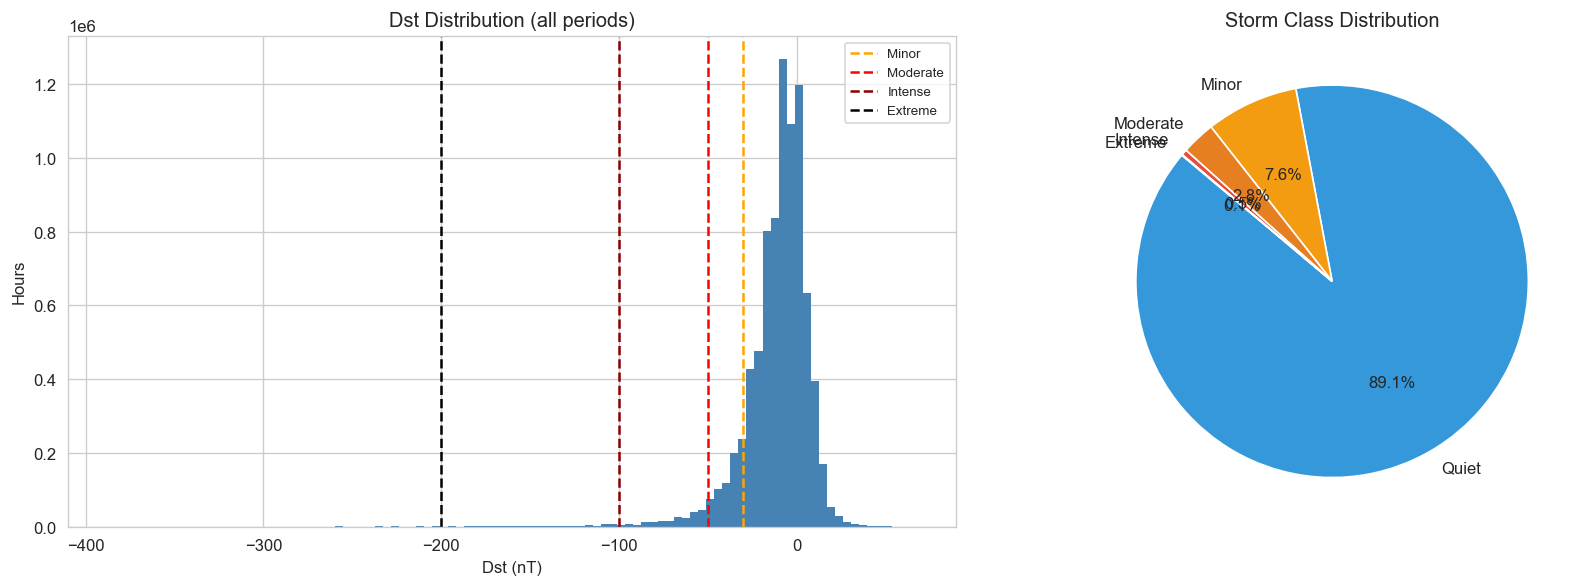

In [13]:
# Hourly Dst values only
dst = df['dst'].dropna()

quiet    = (dst > -30).sum()
minor    = ((dst <= -30) & (dst > -50)).sum()
moderate = ((dst <= -50) & (dst > -100)).sum()
intense  = ((dst <= -100) & (dst > -200)).sum()
extreme  = (dst <= -200).sum()
total    = len(dst)

print('=== Dst Storm Classification ===')
for label, count in [('Quiet (>-30)',      quiet),
                      ('Minor (-30 to -50)', minor),
                      ('Moderate (-50 to -100)', moderate),
                      ('Intense (-100 to -200)', intense),
                      ('Extreme (<-200)',    extreme)]:
    print(f'  {label:30s}: {count:6,} ({100*count/total:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
dst.hist(bins=100, ax=axes[0], color='steelblue', edgecolor='none')
for thresh, color, label in [(-30,'orange','Minor'), (-50,'red','Moderate'),
                               (-100,'darkred','Intense'), (-200,'black','Extreme')]:
    axes[0].axvline(thresh, color=color, linestyle='--', lw=1.5, label=label)
axes[0].set_xlabel('Dst (nT)')
axes[0].set_ylabel('Hours')
axes[0].set_title('Dst Distribution (all periods)')
axes[0].legend(fontsize=8)

# Pie chart
sizes  = [quiet, minor, moderate, intense, extreme]
labels = ['Quiet', 'Minor', 'Moderate', 'Intense', 'Extreme']
colors = ['#3498db', '#f39c12', '#e67e22', '#e74c3c', '#2c3e50']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Storm Class Distribution')

plt.tight_layout()
plt.savefig('dst_distribution.png', dpi=150)
plt.show()

## 4. Burton ODE vs Actual Dst

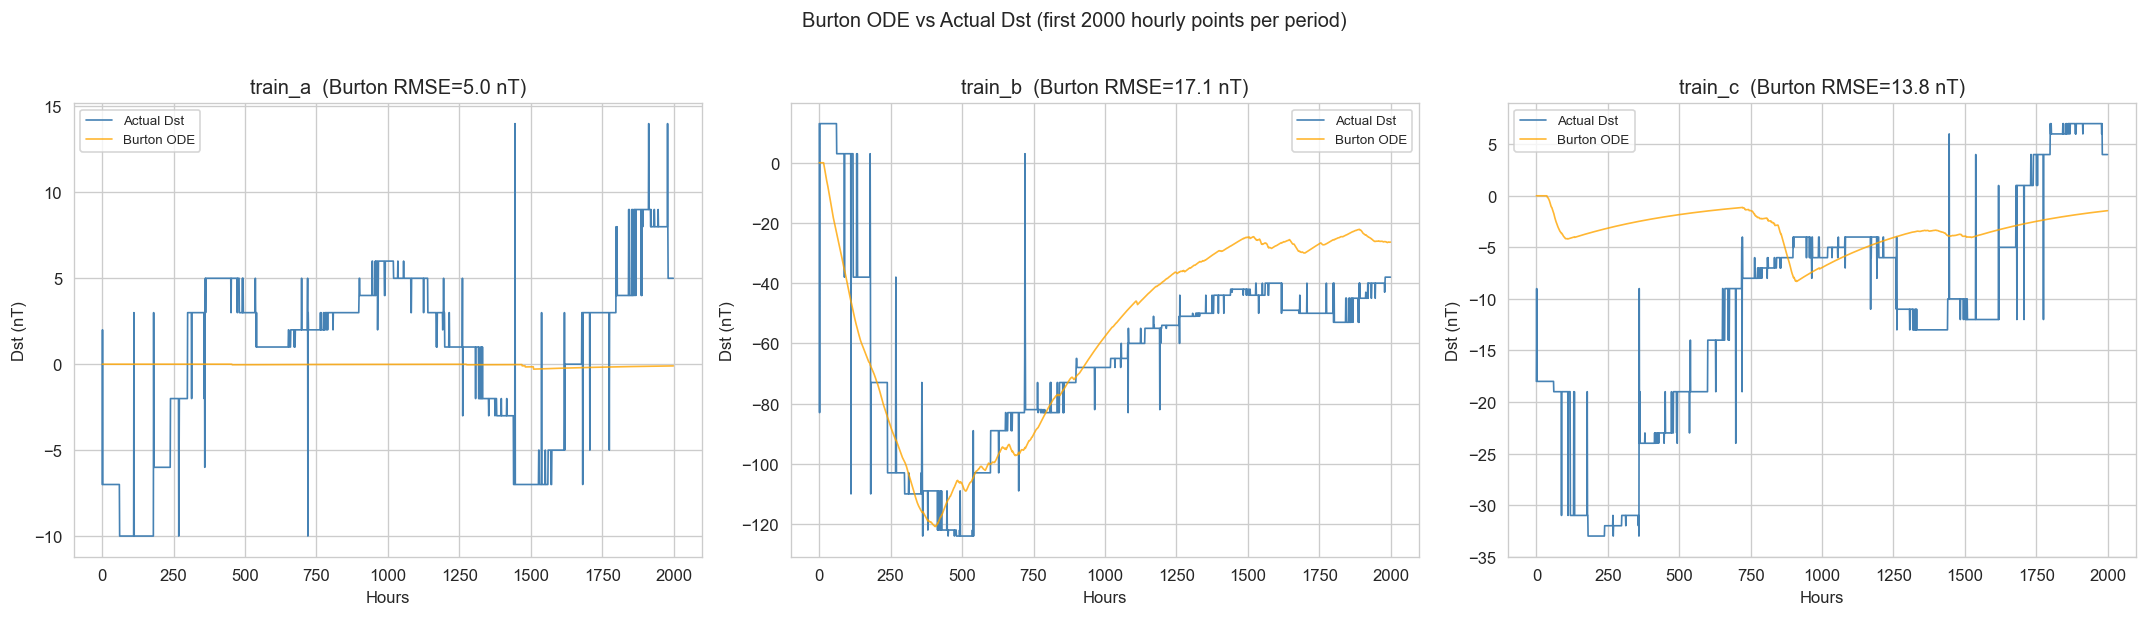

In [14]:
# Use hourly points only (where actual Dst exists)
df_hourly = df.dropna(subset=['dst']).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, period in zip(axes, ['train_a', 'train_b', 'train_c']):
    sub = df_hourly[df_hourly['period'] == period].head(2000)
    ax.plot(sub['dst'].values,        label='Actual Dst',   color='steelblue', lw=1)
    ax.plot(sub['dst_burton'].values,  label='Burton ODE',  color='orange',    lw=1, alpha=0.8)
    rmse = np.sqrt(((sub['dst'] - sub['dst_burton'])**2).mean())
    ax.set_title(f'{period}  (Burton RMSE={rmse:.1f} nT)')
    ax.set_xlabel('Hours')
    ax.set_ylabel('Dst (nT)')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('Burton ODE vs Actual Dst (first 2000 hourly points per period)', y=1.02)
plt.tight_layout()
plt.savefig('burton_vs_actual.png', dpi=150)
plt.show()

## 5. Residual Analysis — What Agent 3 Must Learn

=== Residual Stats (dst_actual - dst_burton) ===
count    139872.000000
mean          0.556502
std          14.410032
min        -210.349106
25%          -6.259812
50%           0.186012
75%           6.860216
max         355.057861
Name: residual, dtype: float64


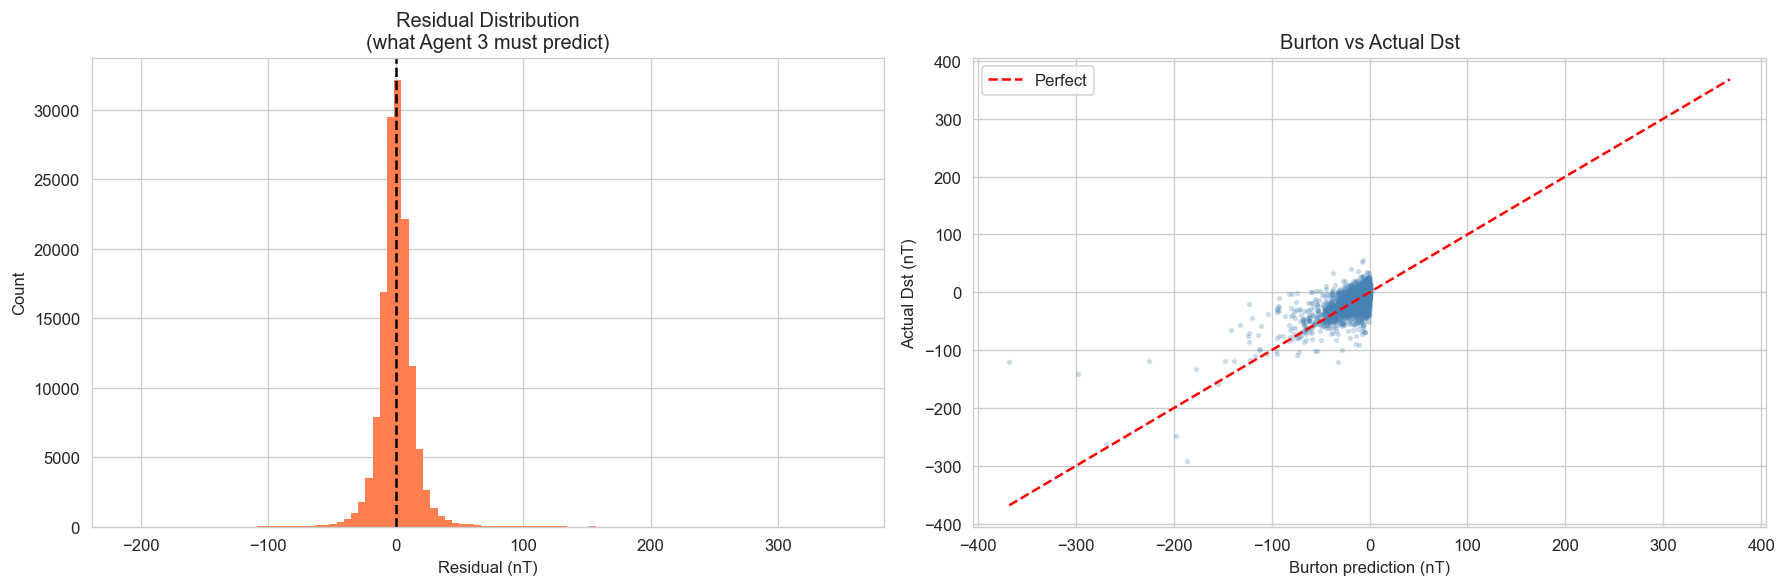


=== Residual RMSE by Storm Severity ===
  Quiet      (n=88,227): RMSE=9.95 nT
  Minor      (n=9,852): RMSE=20.09 nT
  Moderate   (n=3,686): RMSE=35.46 nT
  Intense    (n=  635): RMSE=76.41 nT
  Extreme    (n=   79): RMSE=95.83 nT


In [15]:
residuals = df_hourly['residual'].dropna()

print('=== Residual Stats (dst_actual - dst_burton) ===')
print(residuals.describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual distribution
residuals.hist(bins=100, ax=axes[0], color='coral', edgecolor='none')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Residual (nT)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution\n(what Agent 3 must predict)')

# Scatter: Burton vs Actual
sample = df_hourly.dropna(subset=['dst', 'dst_burton']).sample(5000, random_state=42)
axes[1].scatter(sample['dst_burton'], sample['dst'], alpha=0.2, s=5, color='steelblue')
lim = max(abs(sample['dst']).max(), abs(sample['dst_burton']).max())
axes[1].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Burton prediction (nT)')
axes[1].set_ylabel('Actual Dst (nT)')
axes[1].set_title('Burton vs Actual Dst')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150)
plt.show()

# Residual by storm severity
print('\n=== Residual RMSE by Storm Severity ===')
for label, lo, hi in [('Quiet',    -30,    0),
                        ('Minor',    -50,  -30),
                        ('Moderate', -100, -50),
                        ('Intense',  -200,-100),
                        ('Extreme',  -500,-200)]:
    mask = (df_hourly['dst'] >= lo) & (df_hourly['dst'] < hi)
    r = df_hourly.loc[mask, 'residual'].dropna()
    if len(r) > 0:
        rmse = np.sqrt((r**2).mean())
        print(f'  {label:10s} (n={len(r):5,}): RMSE={rmse:.2f} nT')

## 6. Feature Correlations with Dst

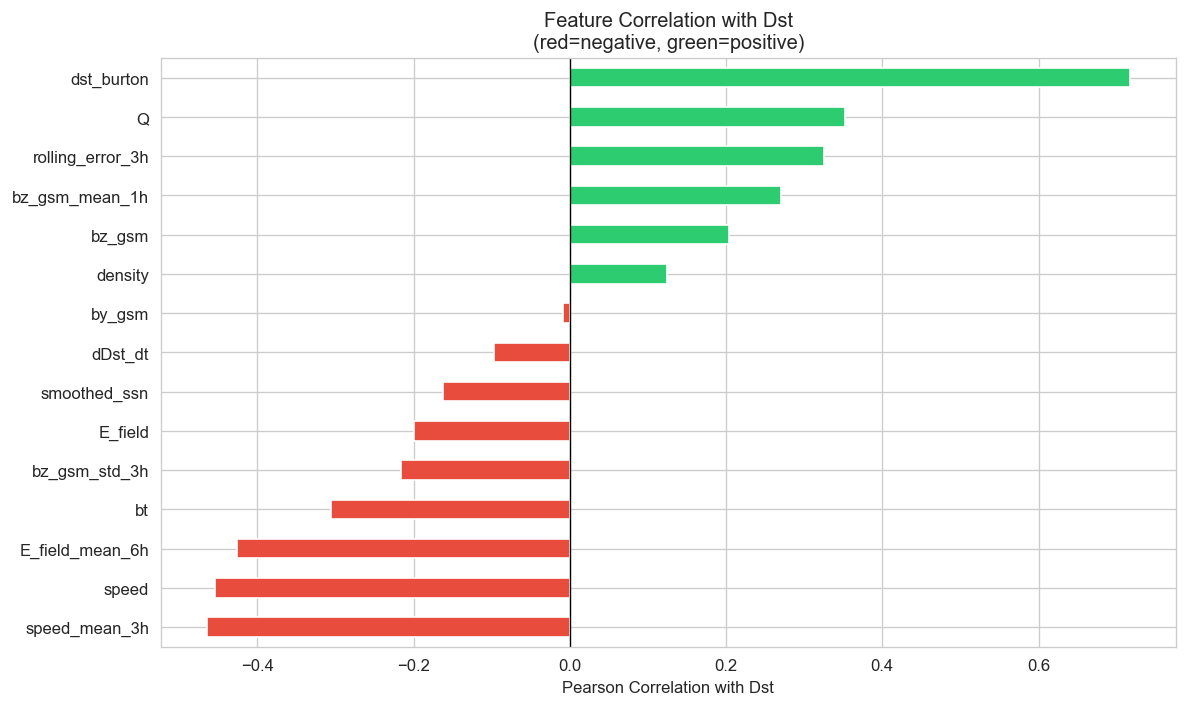

Top 5 most correlated with Dst:
dst_burton         0.716842
speed_mean_3h      0.464389
speed              0.454127
E_field_mean_6h    0.425790
Q                  0.352741
Name: dst, dtype: float64


In [16]:
feature_cols = [
    'bz_gsm', 'by_gsm', 'bt', 'speed', 'density',
    'E_field', 'Q', 'dst_burton', 'dDst_dt',
    'bz_gsm_mean_1h', 'bz_gsm_std_3h',
    'speed_mean_3h', 'E_field_mean_6h',
    'rolling_error_3h', 'smoothed_ssn',
]

corr = df_hourly[feature_cols + ['dst']].corr()['dst'].drop('dst').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with Dst')
ax.set_title('Feature Correlation with Dst\n(red=negative, green=positive)')
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150)
plt.show()

print('Top 5 most correlated with Dst:')
print(corr.abs().sort_values(ascending=False).head())

## 7. Rolling Features vs Dst

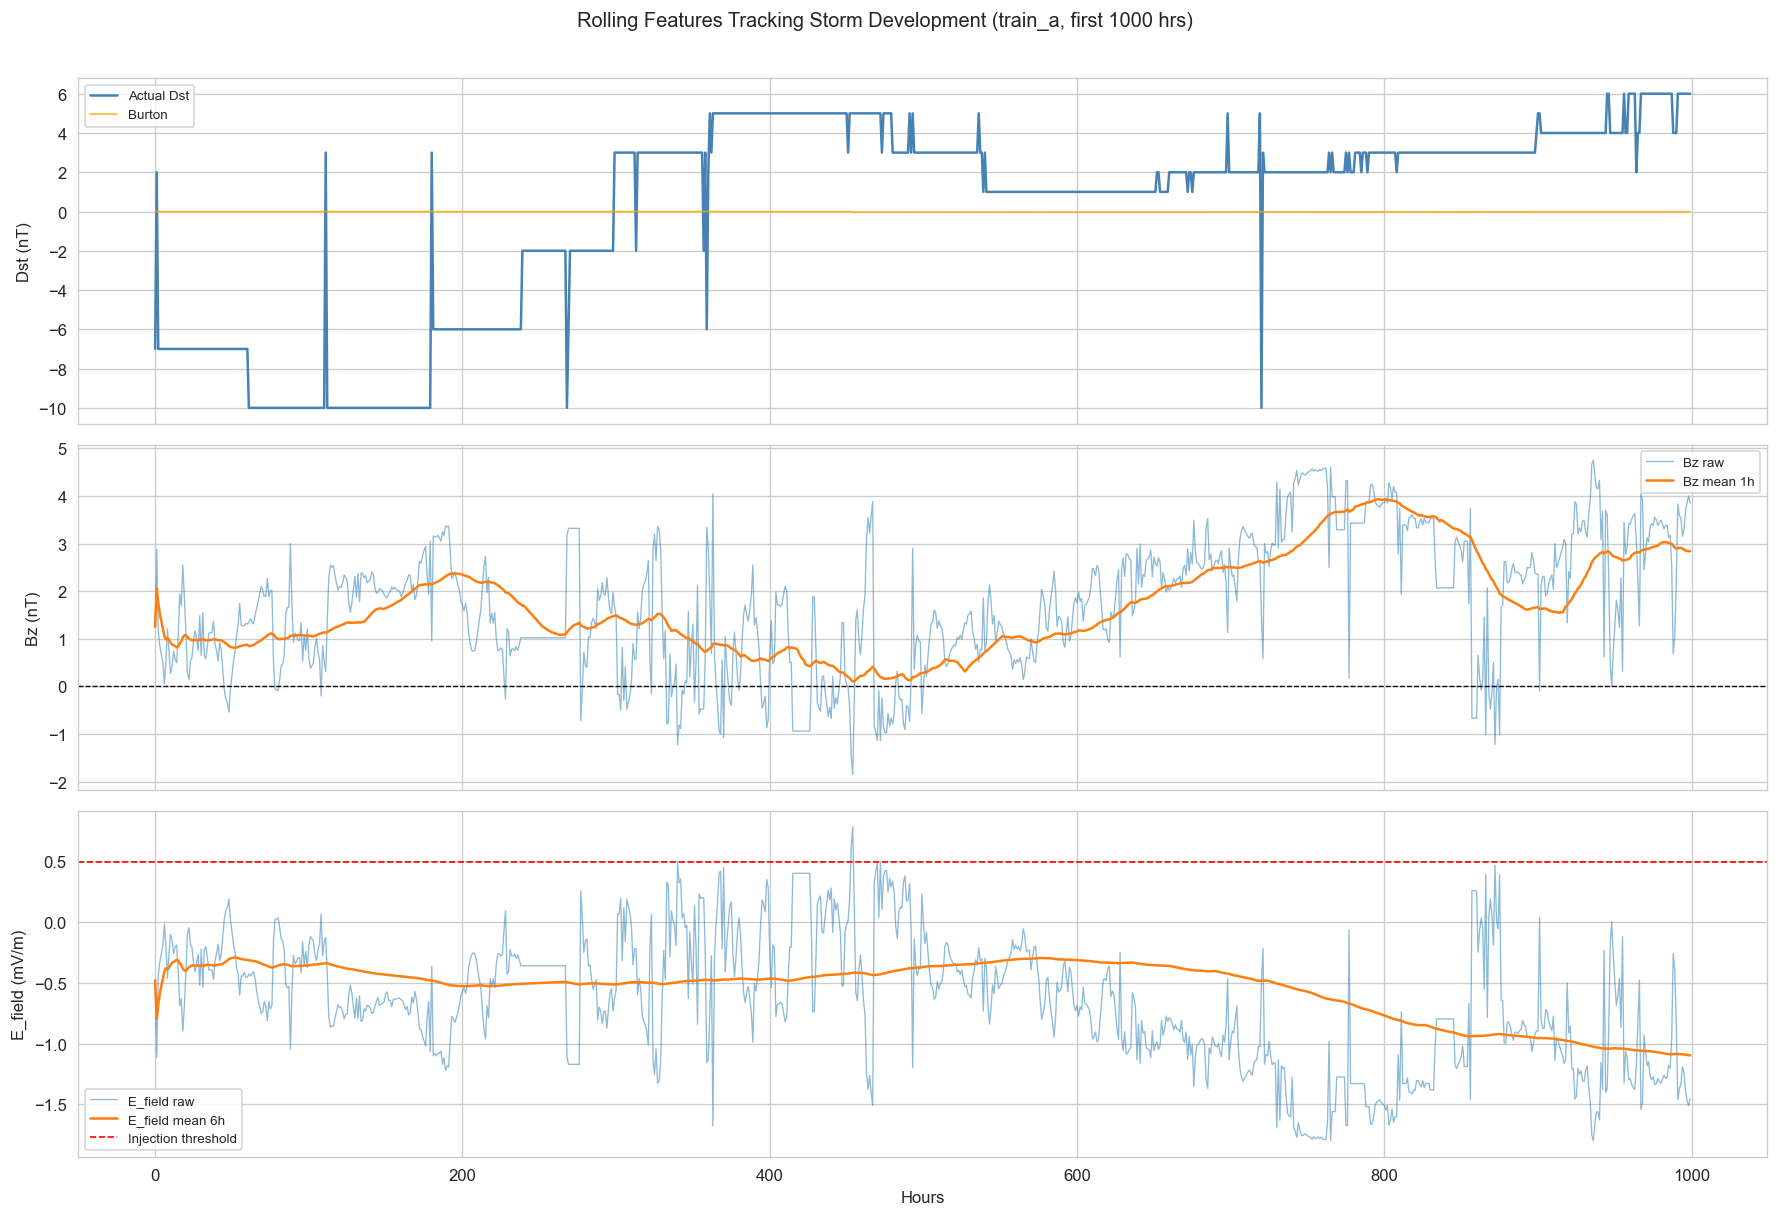

In [17]:
# Show how rolling bz_mean tracks storm development
sub = df_hourly[df_hourly['period'] == 'train_a'].head(1000)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(sub['dst'].values, color='steelblue', lw=1.5, label='Actual Dst')
axes[0].plot(sub['dst_burton'].values, color='orange', lw=1, alpha=0.8, label='Burton')
axes[0].set_ylabel('Dst (nT)')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].plot(sub['bz_gsm'].values,         lw=0.8, alpha=0.5, label='Bz raw')
axes[1].plot(sub['bz_gsm_mean_1h'].values, lw=1.5, label='Bz mean 1h')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_ylabel('Bz (nT)')
axes[1].legend(fontsize=8)
axes[1].grid(True)

axes[2].plot(sub['E_field'].values,          lw=0.8, alpha=0.5, label='E_field raw')
axes[2].plot(sub['E_field_mean_6h'].values,  lw=1.5, label='E_field mean 6h')
axes[2].axhline(0.49, color='red', lw=1, linestyle='--', label='Injection threshold')
axes[2].set_ylabel('E_field (mV/m)')
axes[2].set_xlabel('Hours')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.suptitle('Rolling Features Tracking Storm Development (train_a, first 1000 hrs)', y=1.01)
plt.tight_layout()
plt.savefig('rolling_features.png', dpi=150)
plt.show()

## 8. Storm Phase Analysis

=== Storm Phase Distribution ===
  quiet     :  7,425,906 rows (88.5%)
  onset     :     60,233 rows (0.7%)
  main      :     63,285 rows (0.8%)
  recovery  :    842,896 rows (10.0%)

=== Burton Residual RMSE by Storm Phase ===
  quiet      (n=123,182): RMSE=11.08 nT
  onset      (n=   755): RMSE=20.02 nT
  main       (n= 3,345): RMSE=19.97 nT
  recovery   (n=12,590): RMSE=31.30 nT


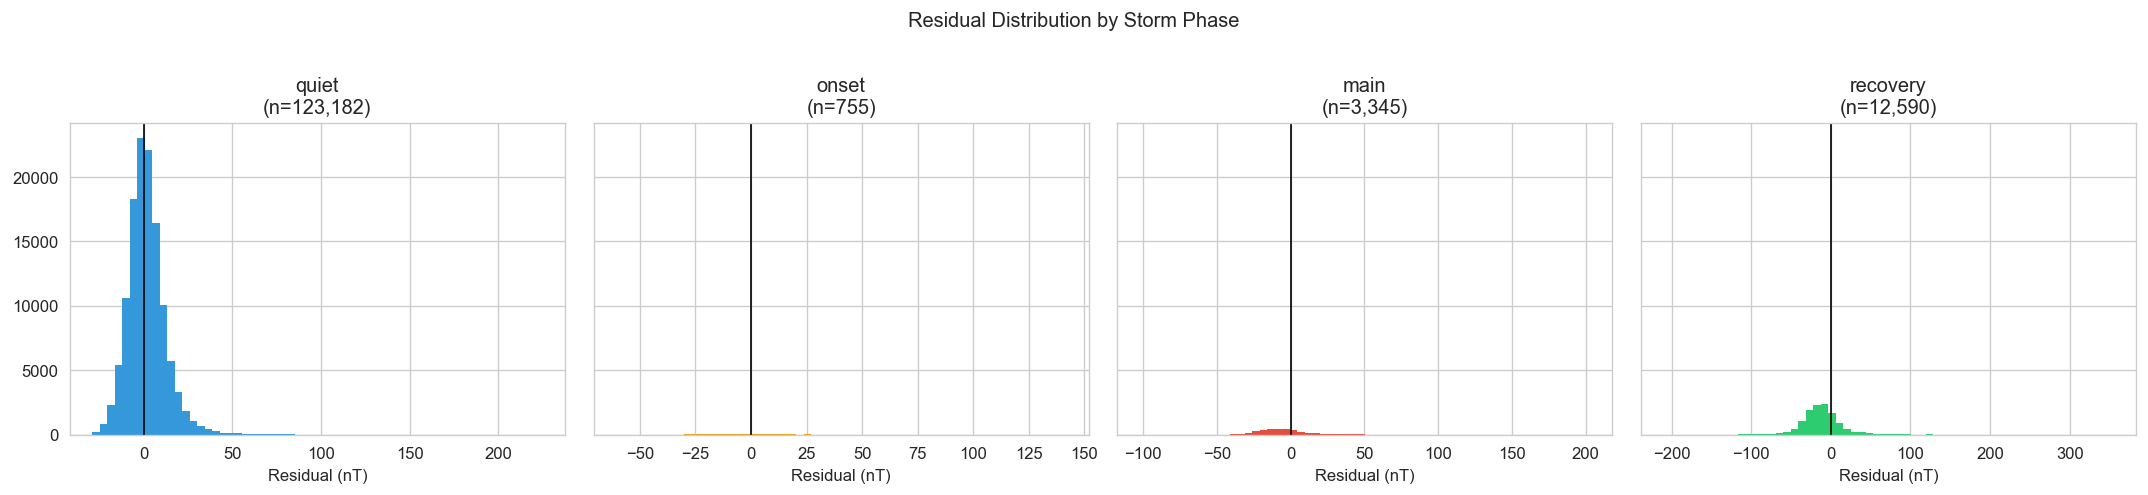

In [18]:
phase_map   = {0: 'quiet', 1: 'onset', 2: 'main', 3: 'recovery'}
phase_colors = {'quiet': '#3498db', 'onset': '#f39c12', 'main': '#e74c3c', 'recovery': '#2ecc71'}

print('=== Storm Phase Distribution ===')
counts = df['storm_phase'].value_counts().sort_index()
for code, name in phase_map.items():
    n = counts.get(code, 0)
    print(f'  {name:10s}: {n:10,} rows ({100*n/len(df):.1f}%)')

# Residual RMSE by storm phase
print('\n=== Burton Residual RMSE by Storm Phase ===')
for code, name in phase_map.items():
    mask = df_hourly['storm_phase'] == code
    r = df_hourly.loc[mask, 'residual'].dropna()
    if len(r) > 0:
        rmse = np.sqrt((r**2).mean())
        print(f'  {name:10s} (n={len(r):6,}): RMSE={rmse:.2f} nT')

# Plot residual distribution per phase
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, (code, name) in zip(axes, phase_map.items()):
    r = df_hourly[df_hourly['storm_phase'] == code]['residual'].dropna()
    r.hist(bins=60, ax=ax, color=phase_colors[name], edgecolor='none')
    ax.set_title(f'{name}\n(n={len(r):,})')
    ax.set_xlabel('Residual (nT)')
    ax.axvline(0, color='black', lw=1)
plt.suptitle('Residual Distribution by Storm Phase', y=1.02)
plt.tight_layout()
plt.savefig('phase_residuals.png', dpi=150)
plt.show()

## 9. Storm Weight Distribution

=== Storm Weight Distribution ===
  weight=    1x  quiet     :  7,475,640 rows (89.08%)
  weight=    3x  minor     :    639,420 rows (7.62%)
  weight=   10x  moderate  :    233,520 rows (2.78%)
  weight=   30x  intense   :     39,000 rows (0.46%)
  weight=  100x  extreme   :      4,740 rows (0.06%)


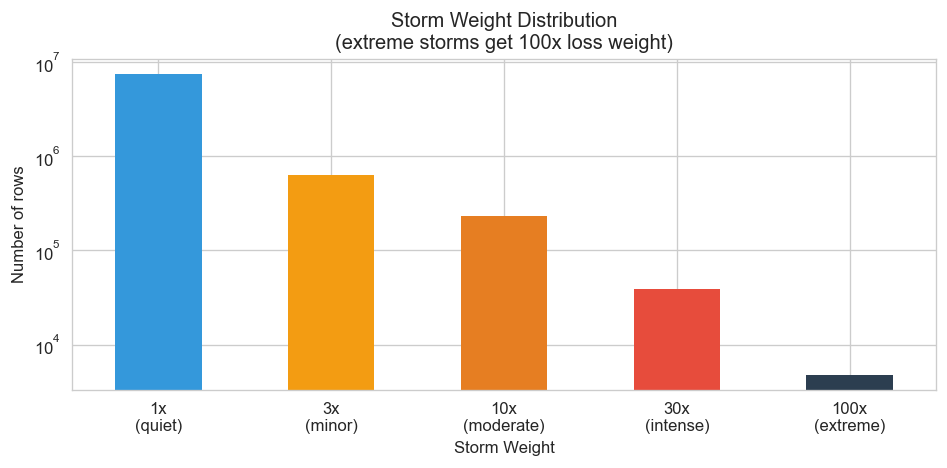

In [19]:
weight_map = {1.0: 'quiet', 3.0: 'minor', 10.0: 'moderate', 30.0: 'intense', 100.0: 'extreme'}

print('=== Storm Weight Distribution ===')
for w, label in weight_map.items():
    n = (df['storm_weight'] == w).sum()
    print(f'  weight={w:5.0f}x  {label:10s}: {n:10,} rows ({100*n/len(df):.2f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
weights = df['storm_weight'].value_counts().sort_index()
colors  = ['#3498db', '#f39c12', '#e67e22', '#e74c3c', '#2c3e50']
weights.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_xticklabels([f'{w:.0f}x\n({weight_map[w]})' for w in weights.index], rotation=0)
ax.set_xlabel('Storm Weight')
ax.set_ylabel('Number of rows')
ax.set_title('Storm Weight Distribution\n(extreme storms get 100x loss weight)')
ax.set_yscale('log')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('storm_weights.png', dpi=150)
plt.show()

## 10. Lag Cross-Correlation Analysis

How many minutes after Bz goes south does Dst start dropping?
The peak lag tells us the optimal `SEQ_LEN` for the LSTM input window.

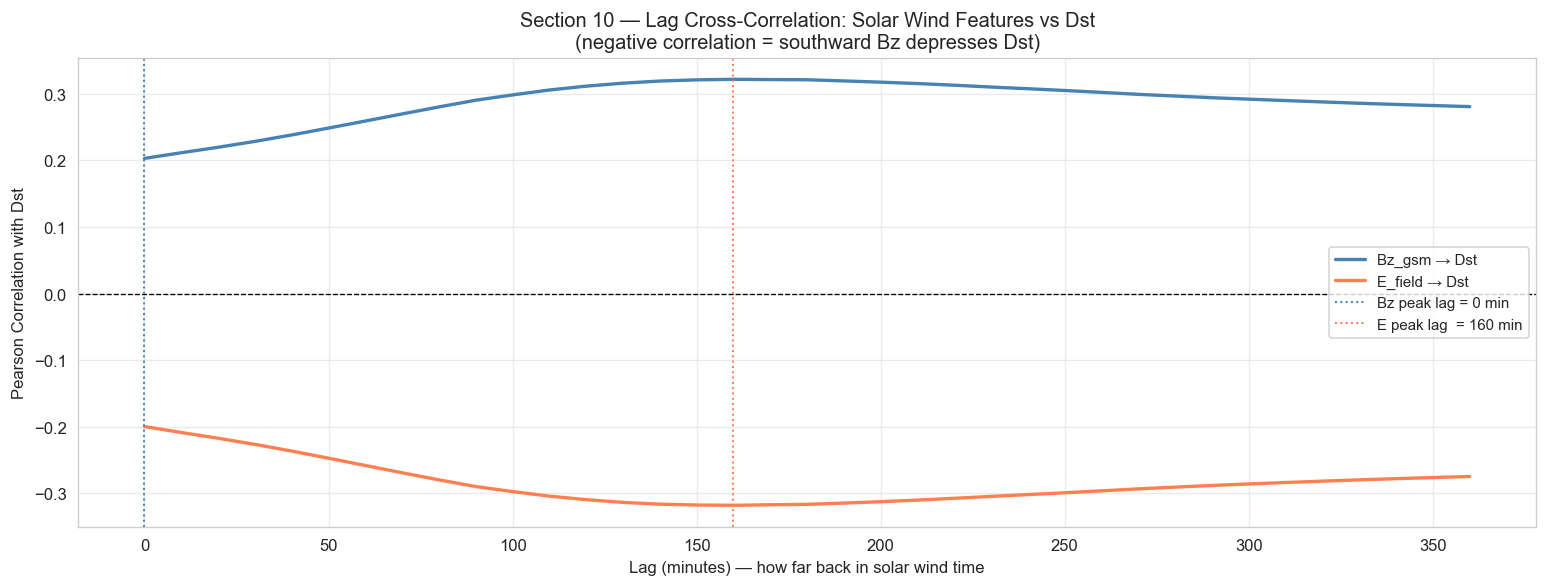

Bz  : peak correlation r=0.203  at lag = 0 min
E   : peak correlation r=-0.318  at lag = 160 min

Implication: SEQ_LEN should cover at least 160 min (currently SEQ_LEN=60 min)


In [20]:

# Cross-correlation per period (avoid mixing periods)
lags_minutes = list(range(0, 361, 10))  # 0 to 360 min in steps of 10

bz_corrs = []
E_corrs  = []

for lag in lags_minutes:
    bz_r, E_r = [], []
    for period in df['period'].unique():
        sub = df[df['period'] == period].copy()
        dst_filled = sub['dst'].ffill(limit=60)
        r_bz = dst_filled.corr(sub['bz_gsm'].shift(lag))
        r_E  = dst_filled.corr(sub['E_field'].shift(lag))
        if not np.isnan(r_bz): bz_r.append(r_bz)
        if not np.isnan(r_E):  E_r.append(r_E)
    bz_corrs.append(np.mean(bz_r))
    E_corrs.append(np.mean(E_r))

best_bz_lag = lags_minutes[int(np.argmin(bz_corrs))]
best_E_lag  = lags_minutes[int(np.argmin(E_corrs))]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(lags_minutes, bz_corrs, color='steelblue', lw=2, label='Bz_gsm → Dst')
ax.plot(lags_minutes, E_corrs,  color='coral',     lw=2, label='E_field → Dst')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axvline(best_bz_lag, color='steelblue', lw=1.2, linestyle=':',
           label=f'Bz peak lag = {best_bz_lag} min')
ax.axvline(best_E_lag,  color='coral',     lw=1.2, linestyle=':',
           label=f'E peak lag  = {best_E_lag} min')
ax.set_xlabel('Lag (minutes) — how far back in solar wind time')
ax.set_ylabel('Pearson Correlation with Dst')
ax.set_title('Section 10 — Lag Cross-Correlation: Solar Wind Features vs Dst\n'
             '(negative correlation = southward Bz depresses Dst)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('lag_correlation.png', dpi=150)
plt.show()

print(f'Bz  : peak correlation r={min(bz_corrs):.3f}  at lag = {best_bz_lag} min')
print(f'E   : peak correlation r={min(E_corrs):.3f}  at lag = {best_E_lag} min')
print(f'\nImplication: SEQ_LEN should cover at least {max(best_bz_lag, best_E_lag)} min '
      f'(currently SEQ_LEN=60 min)')


## 11. Burton Failure Case Studies

Zoom into the deepest storm of each period. Shows where Burton over/under-predicts
and the residual the LSTM must learn. The shaded red area is exactly what Agent 3 corrects.

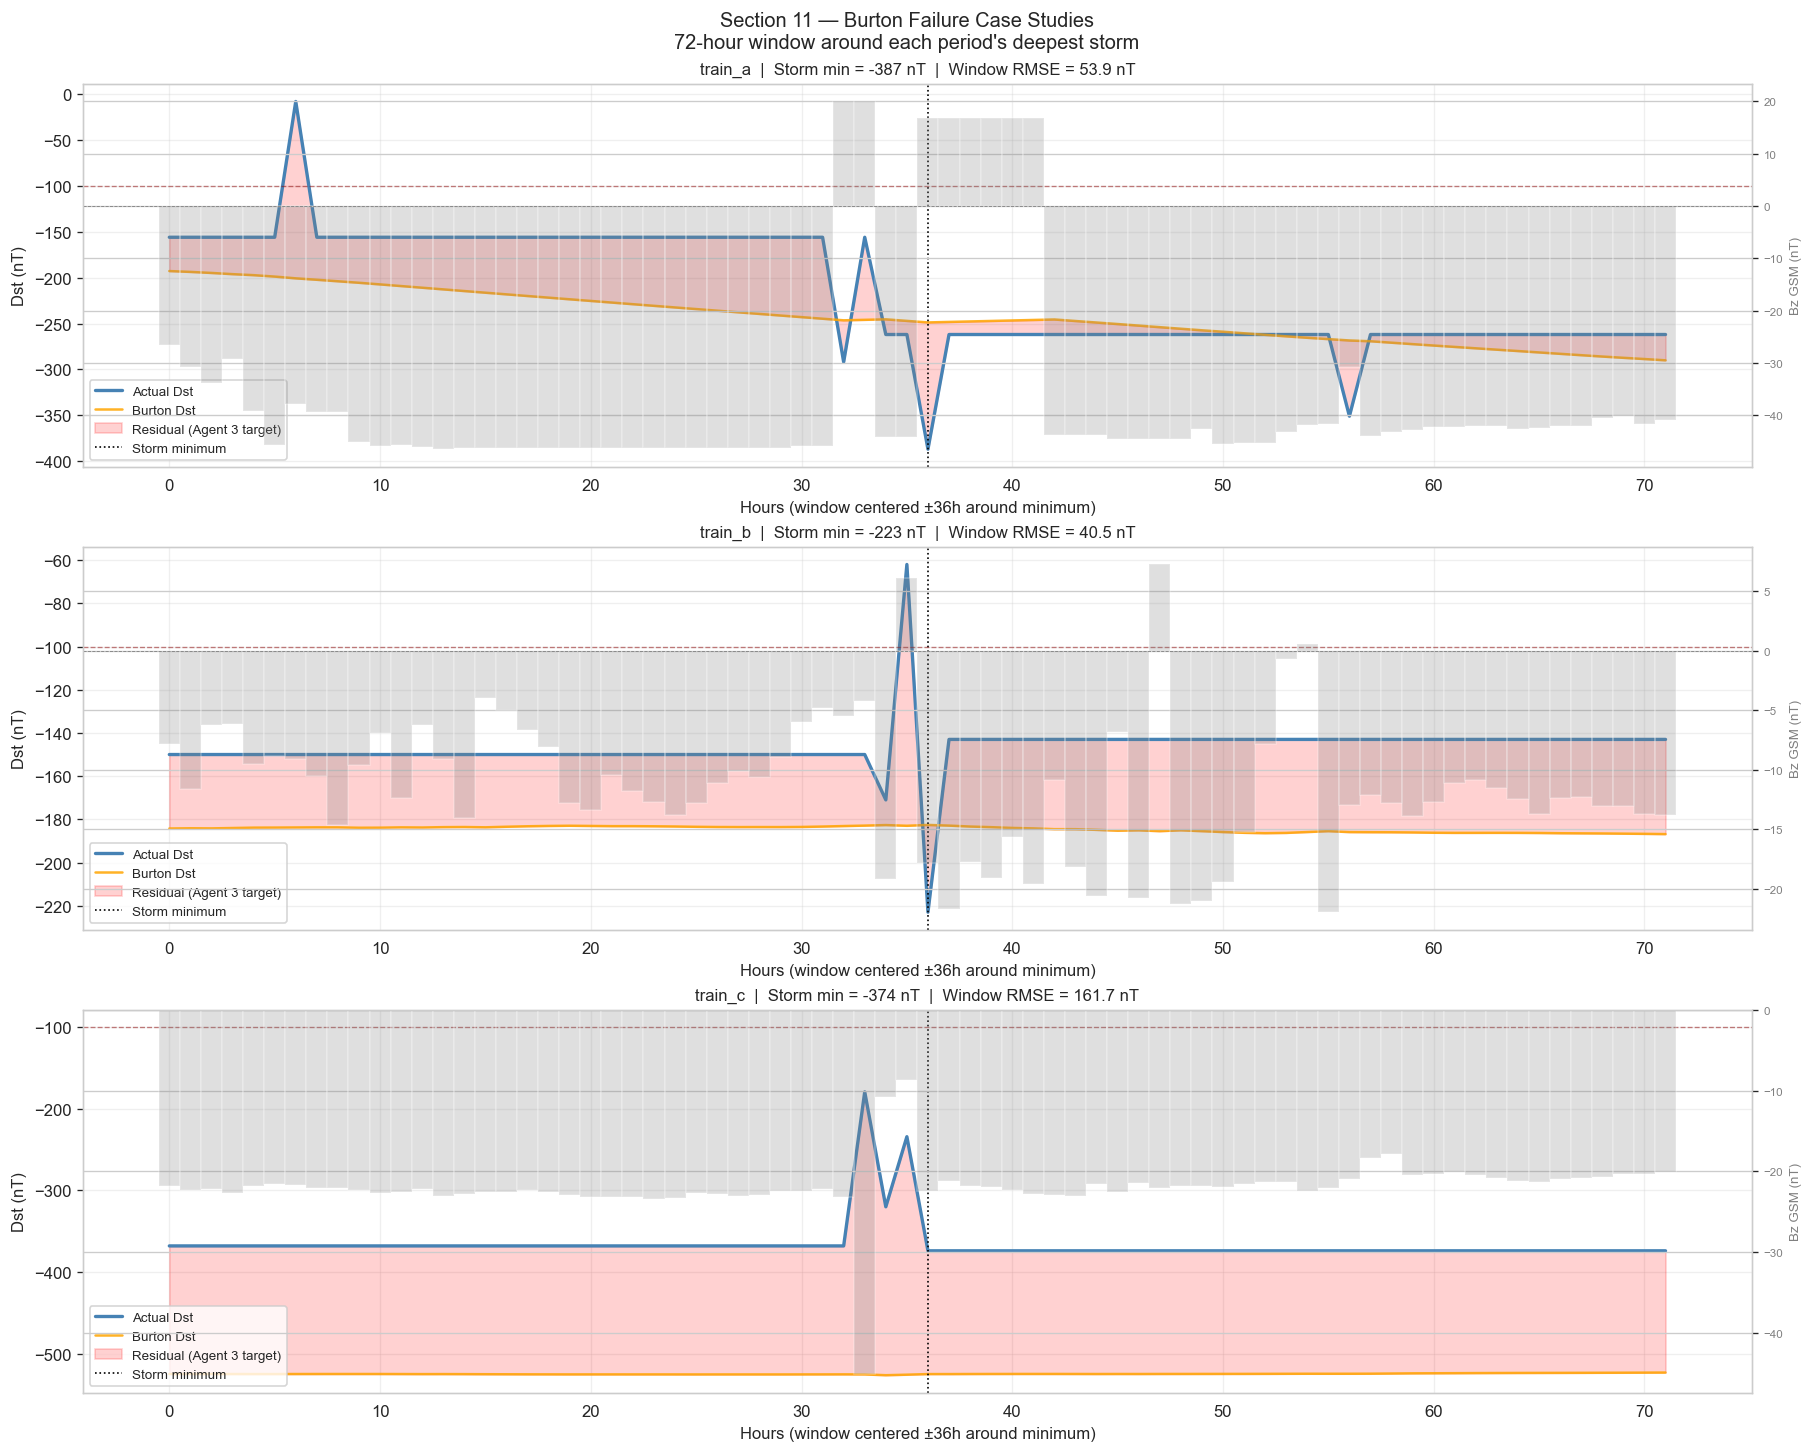

In [21]:

# Find the 3 deepest storms (one per period)
df_hourly = df.dropna(subset=['dst']).copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), constrained_layout=True)

for ax, period in zip(axes, df['period'].unique()):
    sub_h = df_hourly[df_hourly['period'] == period].reset_index(drop=True)
    min_idx = int(sub_h['dst'].idxmin())
    start   = max(0, min_idx - 36)
    end     = min(len(sub_h), min_idx + 36)
    win     = sub_h.iloc[start:end].reset_index(drop=True)
    pivot   = min_idx - start  # position of minimum in window

    ax2 = ax.twinx()
    ax2.bar(range(len(win)), win['bz_gsm'].values, color='gray', alpha=0.25, label='Bz (nT)', width=1)
    ax2.axhline(0, color='gray', lw=0.5, linestyle='--')
    ax2.set_ylabel('Bz GSM (nT)', color='gray', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='gray', labelsize=7)

    ax.plot(win['dst'].values,       color='steelblue', lw=2,   label='Actual Dst')
    ax.plot(win['dst_burton'].values, color='orange',   lw=1.5, alpha=0.85, label='Burton Dst')
    ax.fill_between(range(len(win)), win['dst'].values, win['dst_burton'].values,
                    alpha=0.18, color='red', label='Residual (Agent 3 target)')
    ax.axvline(pivot, color='black', lw=1, linestyle=':', label='Storm minimum')
    ax.axhline(-100, color='darkred', lw=0.8, linestyle='--', alpha=0.5)

    storm_min = sub_h['dst'].min()
    rmse = np.sqrt(((win['dst'] - win['dst_burton'])**2).mean())
    ax.set_title(f'{period}  |  Storm min = {storm_min:.0f} nT  |  Window RMSE = {rmse:.1f} nT',
                 fontsize=10)
    ax.set_ylabel('Dst (nT)')
    ax.set_xlabel('Hours (window centered ±36h around minimum)')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Section 11 — Burton Failure Case Studies\n'
             '72-hour window around each period\'s deepest storm', fontsize=12)
plt.savefig('burton_failure_cases.png', dpi=150)
plt.show()


## 12. ACE vs DSCOVR Satellite Comparison

The dataset spans two satellites (ACE 1998–2016, DSCOVR 2016–present).
Do they have the same distributions? Systematic bias? This justifies keeping `source_encoded` as a feature.

ACE rows    : 8,392,320  (100.0%)
DSCOVR rows : 0  (0.0%)

Feature                 ACE mean   DSCOVR mean      Diff
bz_gsm                    -0.030           nan      +nan
speed                    429.973           nan      +nan
bt                         5.612           nan      +nan
density                    4.405           nan      +nan
temperature           112737.740           nan      +nan
E_field                    0.021           nan      +nan


c:\Users\adnan\OneDrive\Desktop\Projects\Solar_Winds\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\adnan\OneDrive\Desktop\Projects\Solar_Winds\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\adnan\OneDrive\Desktop\Projects\Solar_Winds\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\adnan\OneDrive\Desktop\Projects\Solar_Winds\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
c:\Users\adnan\OneDrive\Desktop\Projects\Solar_Winds\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


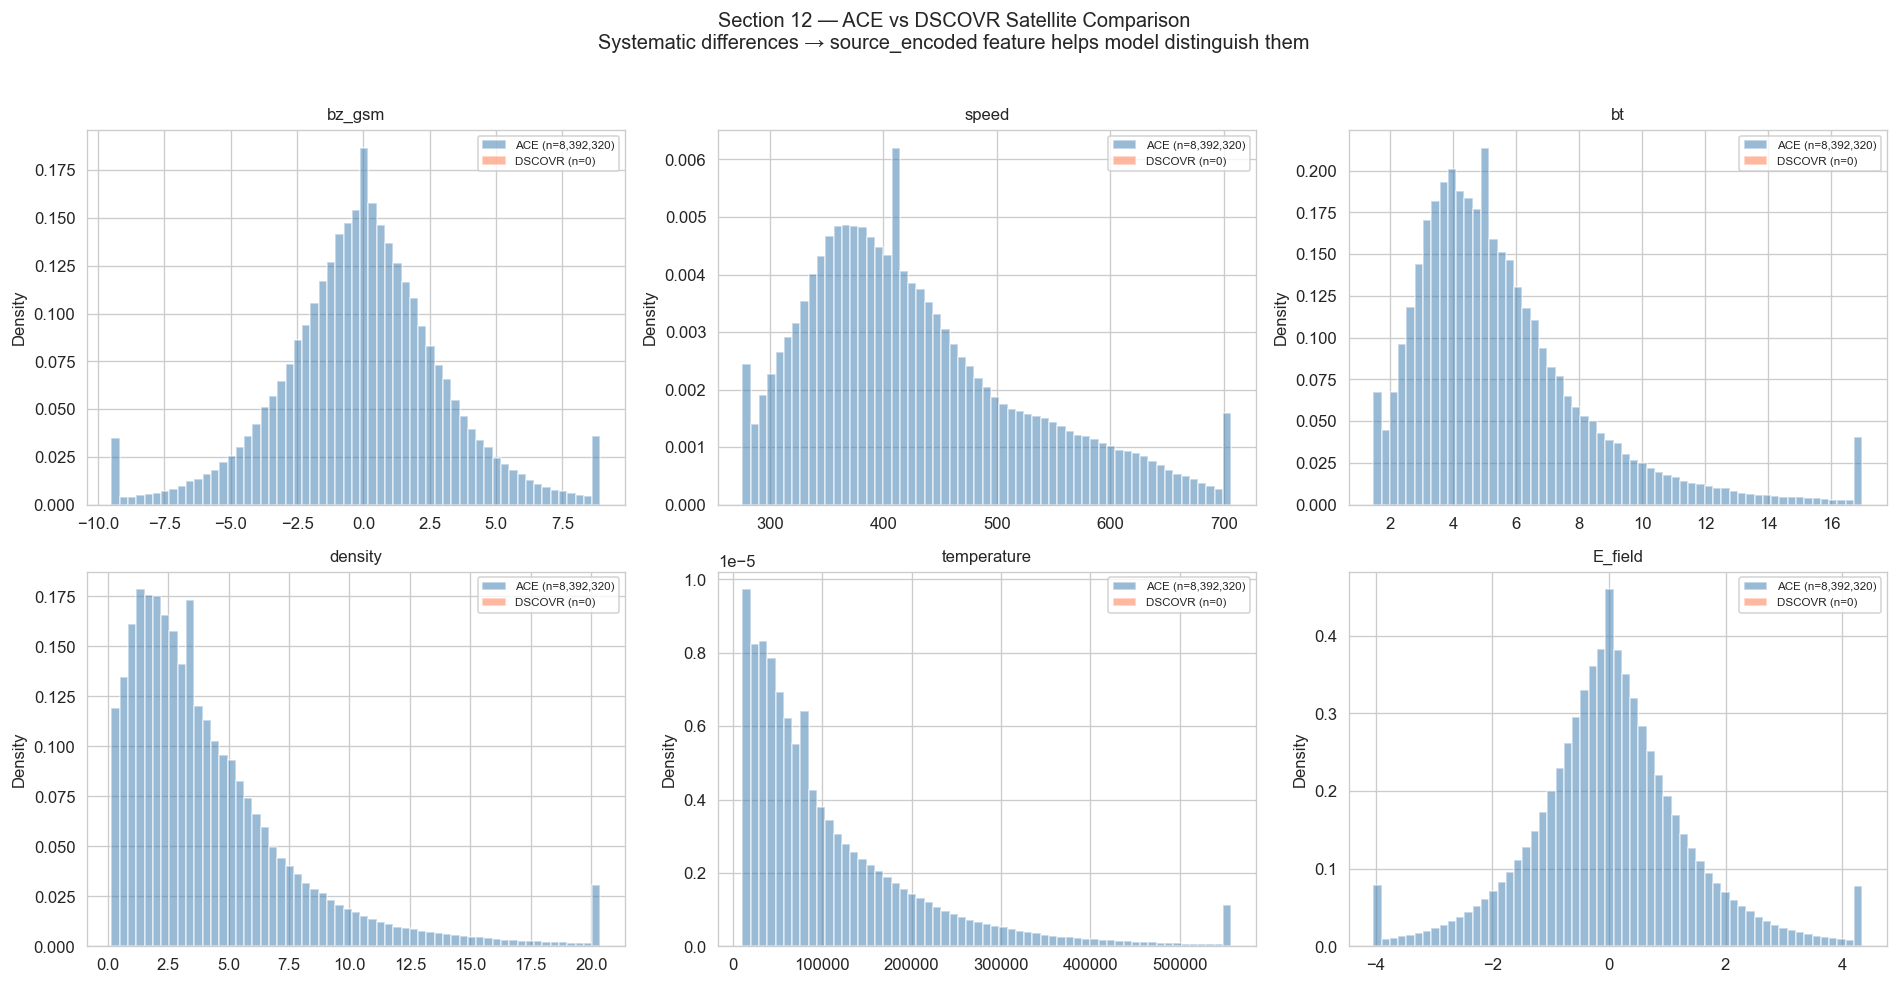

In [23]:

ace    = df[df['source_encoded'] == 0]
dscovr = df[df['source_encoded'] == 1]


print(f'ACE rows    : {len(ace):,}  ({100*len(ace)/len(df):.1f}%)')
print(f'DSCOVR rows : {len(dscovr):,}  ({100*len(dscovr)/len(df):.1f}%)')
print()

compare_feats = ['bz_gsm', 'speed', 'bt', 'density', 'temperature', 'E_field']
print(f'{"Feature":20s}  {"ACE mean":>10s}  {"DSCOVR mean":>12s}  {"Diff":>8s}')
for feat in compare_feats:
    a = ace[feat].dropna().mean()
    d = dscovr[feat].dropna().mean()
    print(f'{feat:20s}  {a:10.3f}  {d:12.3f}  {d-a:+8.3f}')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, feat in zip(axes.flat, compare_feats):
    ace_v    = ace[feat].dropna()
    dscovr_v = dscovr[feat].dropna()
    lo = np.percentile(pd.concat([ace_v, dscovr_v]), 1)
    hi = np.percentile(pd.concat([ace_v, dscovr_v]), 99)
    bins = np.linspace(lo, hi, 60)

    ax.hist(ace_v.clip(lo, hi),    bins=bins, alpha=0.55,
            color='steelblue', label=f'ACE (n={len(ace_v):,})',    density=True)
    ax.hist(dscovr_v.clip(lo, hi), bins=bins, alpha=0.55,
            color='coral',     label=f'DSCOVR (n={len(dscovr_v):,})', density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Section 12 — ACE vs DSCOVR Satellite Comparison\n'
             'Systematic differences → source_encoded feature helps model distinguish them',
             y=1.02)
plt.tight_layout()
plt.savefig('ace_vs_dscovr.png', dpi=150)
plt.show()


## 13. Residual Autocorrelation (ACF / PACF)

If the residual at hour T correlates with hour T+1, T+2 …, the LSTM can exploit that
temporal structure. Significant ACF lags validate using a sequence model over a simple feedforward net.

Residual series: 28824 hourly points
Mean=1.57 nT   Std=21.63 nT


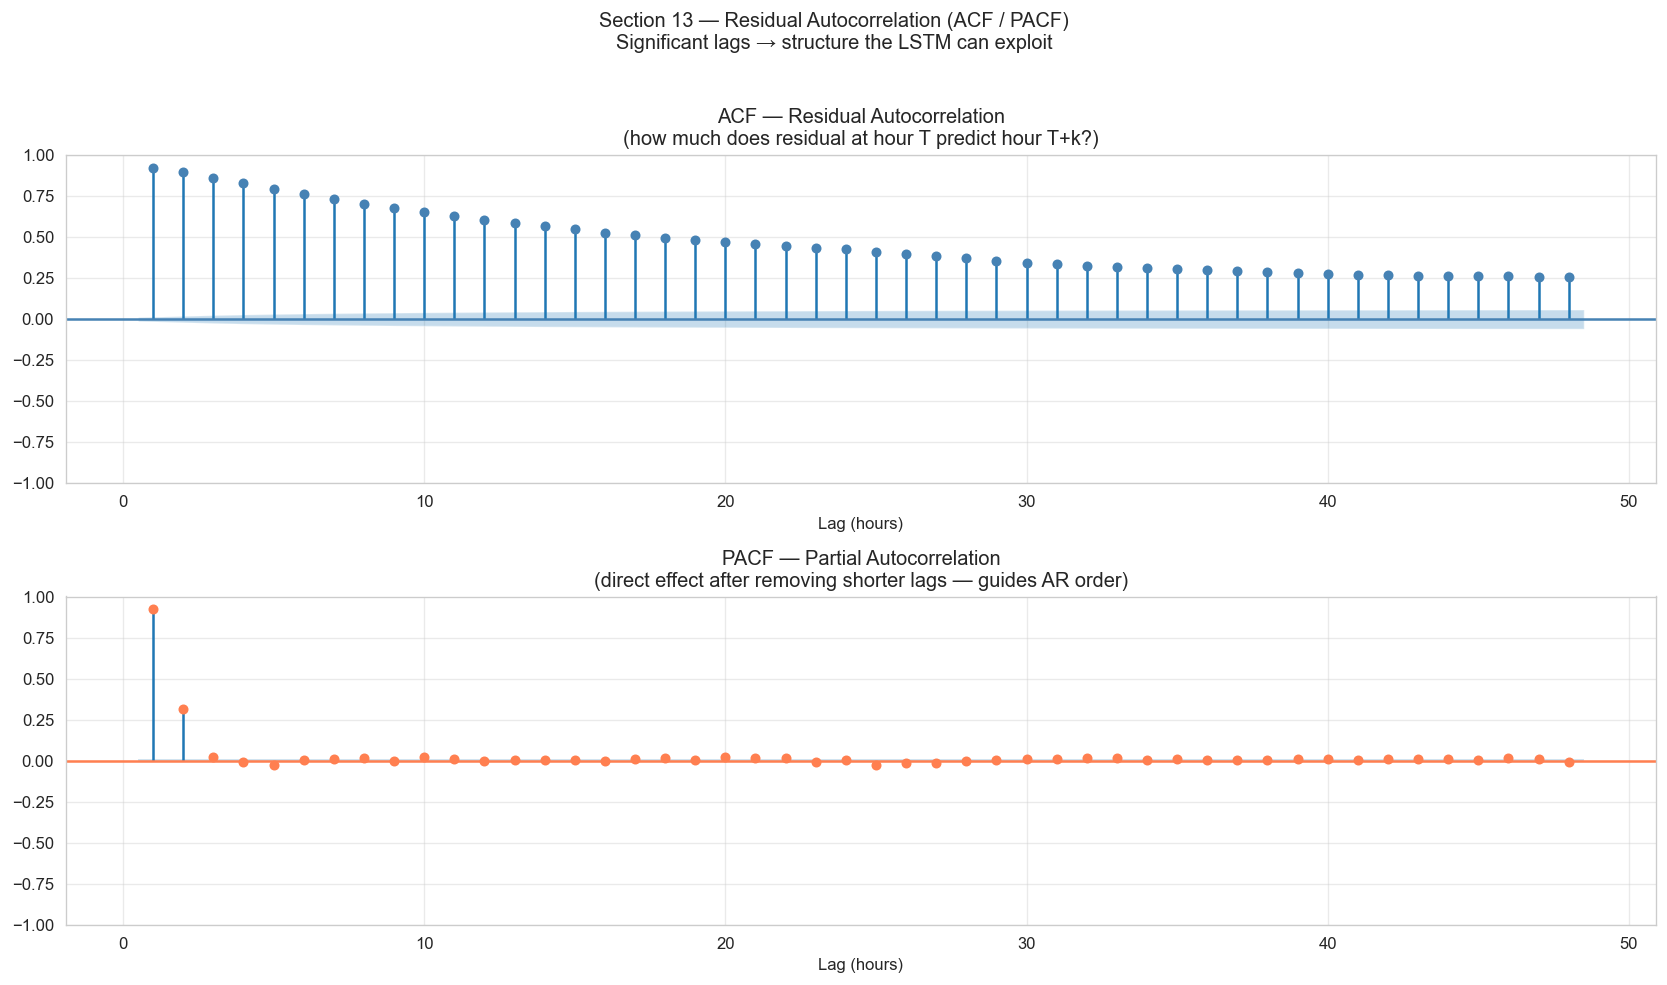


Significant lags (|ACF| > 0.10):
  Lag  1h : ACF = 0.923
  Lag  2h : ACF = 0.898
  Lag  3h : ACF = 0.861
  Lag  4h : ACF = 0.828
  Lag  5h : ACF = 0.792
  Lag  6h : ACF = 0.760
  Lag  7h : ACF = 0.730
  Lag  8h : ACF = 0.702
  Lag  9h : ACF = 0.674
  Lag 10h : ACF = 0.651
  Lag 11h : ACF = 0.628
  Lag 12h : ACF = 0.606
  Lag 13h : ACF = 0.585
  Lag 14h : ACF = 0.566
  Lag 15h : ACF = 0.547
  Lag 16h : ACF = 0.528
  Lag 17h : ACF = 0.511
  Lag 18h : ACF = 0.495
  Lag 19h : ACF = 0.479
  Lag 20h : ACF = 0.467
  Lag 21h : ACF = 0.456
  Lag 22h : ACF = 0.446
  Lag 23h : ACF = 0.434
  Lag 24h : ACF = 0.425
  Lag 25h : ACF = 0.411
  Lag 26h : ACF = 0.398
  Lag 27h : ACF = 0.383
  Lag 28h : ACF = 0.369
  Lag 29h : ACF = 0.356
  Lag 30h : ACF = 0.345
  Lag 31h : ACF = 0.334
  Lag 32h : ACF = 0.325
  Lag 33h : ACF = 0.317
  Lag 34h : ACF = 0.309
  Lag 35h : ACF = 0.303
  Lag 36h : ACF = 0.296
  Lag 37h : ACF = 0.290
  Lag 38h : ACF = 0.285
  Lag 39h : ACF = 0.279
  Lag 40h : ACF = 0.275
  Lag 

In [25]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf as compute_acf

# Use train_a hourly residuals (longest contiguous sequence)
res_series = (
    df[df['period'] == 'train_a']
    .dropna(subset=['residual'])['residual']
    .reset_index(drop=True)
)
print(f'Residual series: {len(res_series)} hourly points')
print(f'Mean={res_series.mean():.2f} nT   Std={res_series.std():.2f} nT')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(res_series, lags=48, ax=axes[0], alpha=0.05, color='steelblue', zero=False)
axes[0].set_title('ACF — Residual Autocorrelation\n'
                  '(how much does residual at hour T predict hour T+k?)')
axes[0].set_xlabel('Lag (hours)')
axes[0].grid(True, alpha=0.4)

plot_pacf(res_series, lags=48, ax=axes[1], alpha=0.05, color='coral', method='ywm', zero=False)
axes[1].set_title('PACF — Partial Autocorrelation\n'
                  '(direct effect after removing shorter lags — guides AR order)')
axes[1].set_xlabel('Lag (hours)')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Section 13 — Residual Autocorrelation (ACF / PACF)\n'
             'Significant lags → structure the LSTM can exploit', y=1.02)
plt.tight_layout()
plt.savefig('residual_acf_pacf.png', dpi=150)
plt.show()

acf_vals = compute_acf(res_series, nlags=48, fft=True)
print('\nSignificant lags (|ACF| > 0.10):')
for lag, val in enumerate(acf_vals):
    if lag > 0 and abs(val) > 0.10:
        print(f'  Lag {lag:2d}h : ACF = {val:.3f}')


## 14. Solar Cycle Effect

Does storm frequency follow the sunspot cycle (solar max ≈ more storms)?
Validates why different periods have different storm statistics.

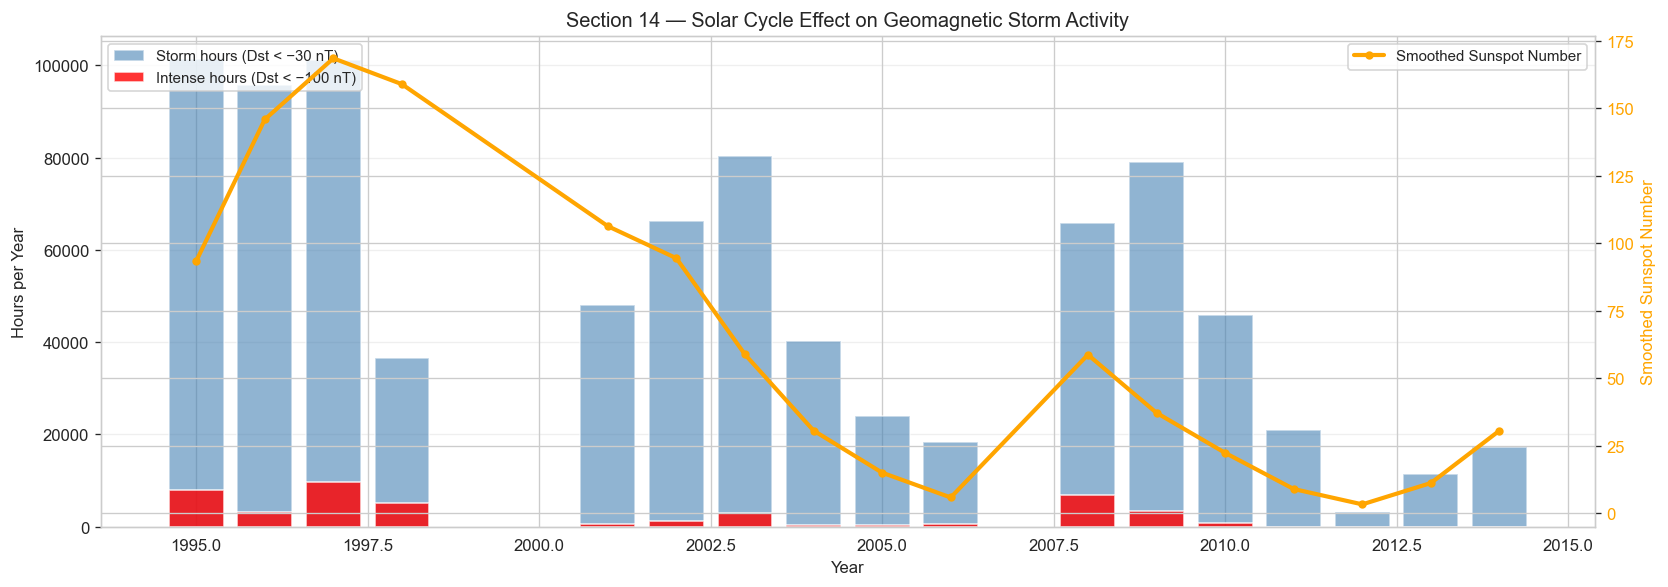

Pearson r (sunspot number vs storm hours per year): 0.679
High r → solar max drives more storms → model must handle solar-cycle variation


In [26]:

# Map each period to approximate start year
period_start = {'train_a': 1995, 'train_b': 2001, 'train_c': 2008}

df_hourly2 = df.dropna(subset=['dst']).copy()
records = []

for period in df['period'].unique():
    start_yr = period_start[period]
    sub = df_hourly2[df_hourly2['period'] == period].copy()
    sub['year'] = start_yr + (sub['timedelta'].dt.total_seconds() / (365.25 * 24 * 3600)).astype(int)

    for yr in sorted(sub['year'].unique()):
        yr_data = sub[sub['year'] == yr]
        records.append({
            'year':          yr,
            'ssn':           yr_data['smoothed_ssn'].mean(),
            'storm_hours':   int((yr_data['dst'] < -30).sum()),
            'intense_hours': int((yr_data['dst'] < -100).sum()),
        })

df_cycle = pd.DataFrame(records).sort_values('year')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(df_cycle['year'], df_cycle['storm_hours'],
        color='steelblue', alpha=0.6, label='Storm hours (Dst < −30 nT)')
ax1.bar(df_cycle['year'], df_cycle['intense_hours'],
        color='red',       alpha=0.8, label='Intense hours (Dst < −100 nT)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Hours per Year')
ax1.legend(loc='upper left', fontsize=9)

ax2.plot(df_cycle['year'], df_cycle['ssn'],
         color='orange', lw=2.5, marker='o', ms=4, label='Smoothed Sunspot Number')
ax2.set_ylabel('Smoothed Sunspot Number', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='upper right', fontsize=9)

ax1.set_title('Section 14 — Solar Cycle Effect on Geomagnetic Storm Activity')
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('solar_cycle_effect.png', dpi=150)
plt.show()

r = df_cycle['ssn'].corr(df_cycle['storm_hours'])
print(f'Pearson r (sunspot number vs storm hours per year): {r:.3f}')
print('High r → solar max drives more storms → model must handle solar-cycle variation')


## 15. Feature Distributions — All 14 LSTM Input Features

Histograms of every feature the LSTM sees. High skewness (|skew| > 2, red title)
means StandardScaler alone may not be enough — log-transform could improve training.

LSTM input features (14):
  bz_gsm                     mean=   -0.030  std=   3.424  skew=-0.34
  speed                      mean=  429.973  std=  99.785  skew=+0.93
  E_field                    mean=    0.021  std=   1.609  skew=+0.65
  Q                          mean=   -1.508  std=   4.067  skew=-8.03
  dst_burton                 mean=  -11.610  std=  18.817  skew=-6.98
  dDst_dt                    mean=   -0.000  std=   3.254  skew=-5.42
  rolling_error_3h           mean=    0.554  std=  13.864  skew=+1.63
  bz_gsm_mean_1h             mean=   -0.030  std=   2.904  skew=-0.50
  bz_gsm_std_3h              mean=    1.800  std=   1.327  skew=+3.26
  speed_mean_3h              mean=  429.975  std=  98.380  skew=+0.90
  E_field_mean_6h            mean=    0.021  std=   1.075  skew=+1.24
  storm_phase                mean=    0.324  std=   0.915  skew=+2.53
  source_encoded             mean=    0.000  std=   0.000  skew=+0.00
  smoothed_ssn               mean=   58.087  std=  52.458  skew=

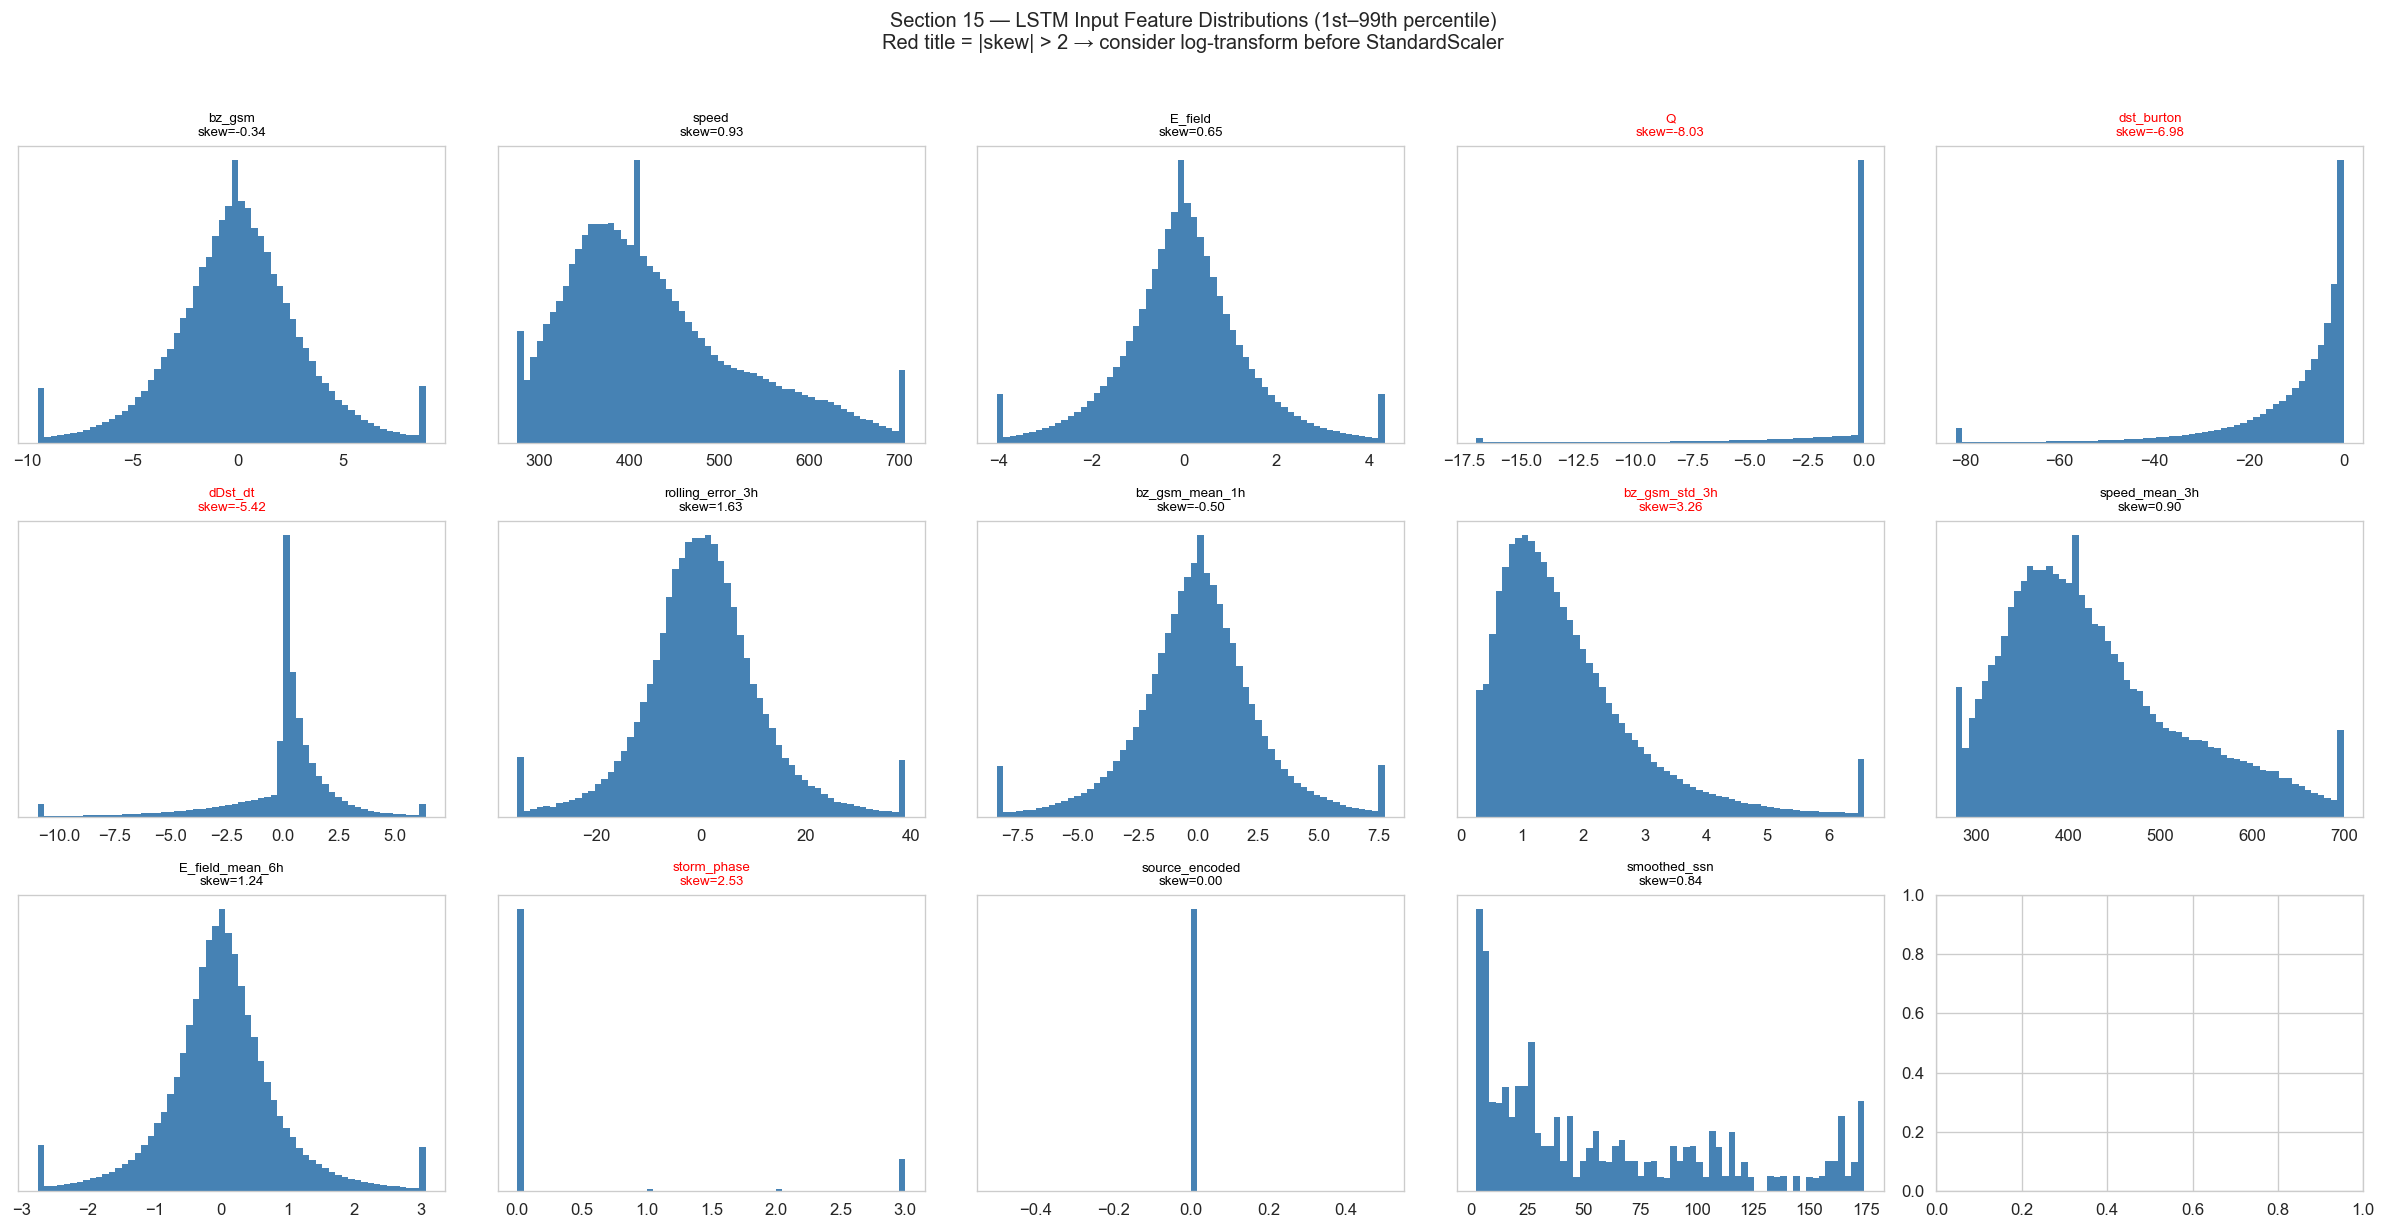


High-skew features (|skew| > 2) — may need log-transform:
  Q                        : skew=-8.03
  dst_burton               : skew=-6.98
  dDst_dt                  : skew=-5.42
  bz_gsm_std_3h            : skew=3.26
  storm_phase              : skew=2.53


In [28]:

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.lstm_corrector import FEATURE_COLS


available_features = [c for c in FEATURE_COLS if c in df.columns]
print(f'LSTM input features ({len(available_features)}):')
for f in available_features:
    vals = df[f].dropna()
    skew = vals.skew()
    print(f'  {f:25s}  mean={vals.mean():9.3f}  std={vals.std():8.3f}  skew={skew:+.2f}')

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes_flat = axes.flat

for ax, feat in zip(axes_flat, available_features):
    vals = df[feat].dropna()
    lo   = np.percentile(vals, 1)
    hi   = np.percentile(vals, 99)
    vals.clip(lo, hi).hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
    skew = vals.skew()
    color = 'red' if abs(skew) > 2 else 'black'
    ax.set_title(f'{feat}\nskew={skew:.2f}', fontsize=8, color=color)
    ax.set_yticks([])
    ax.grid(False)

for ax in list(axes_flat)[len(available_features):]:
    ax.set_visible(False)

plt.suptitle(
    'Section 15 — LSTM Input Feature Distributions (1st–99th percentile)\n'
    'Red title = |skew| > 2 → consider log-transform before StandardScaler',
    y=1.02
)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

print('\nHigh-skew features (|skew| > 2) — may need log-transform:')
for feat in available_features:
    skew = df[feat].dropna().skew()
    if abs(skew) > 2:
        print(f'  {feat:25s}: skew={skew:.2f}')


## 16. LSTM Input Sequence Visualization

Show the actual 60-minute window the LSTM sees right before a storm onset.
Each subplot is one feature. Red dashed line = the prediction moment.

Storm onset timedelta : 1 days 23:59:00
Dst at onset          : -95 nT
Window rows           : 60 minutes
Features available    : 14


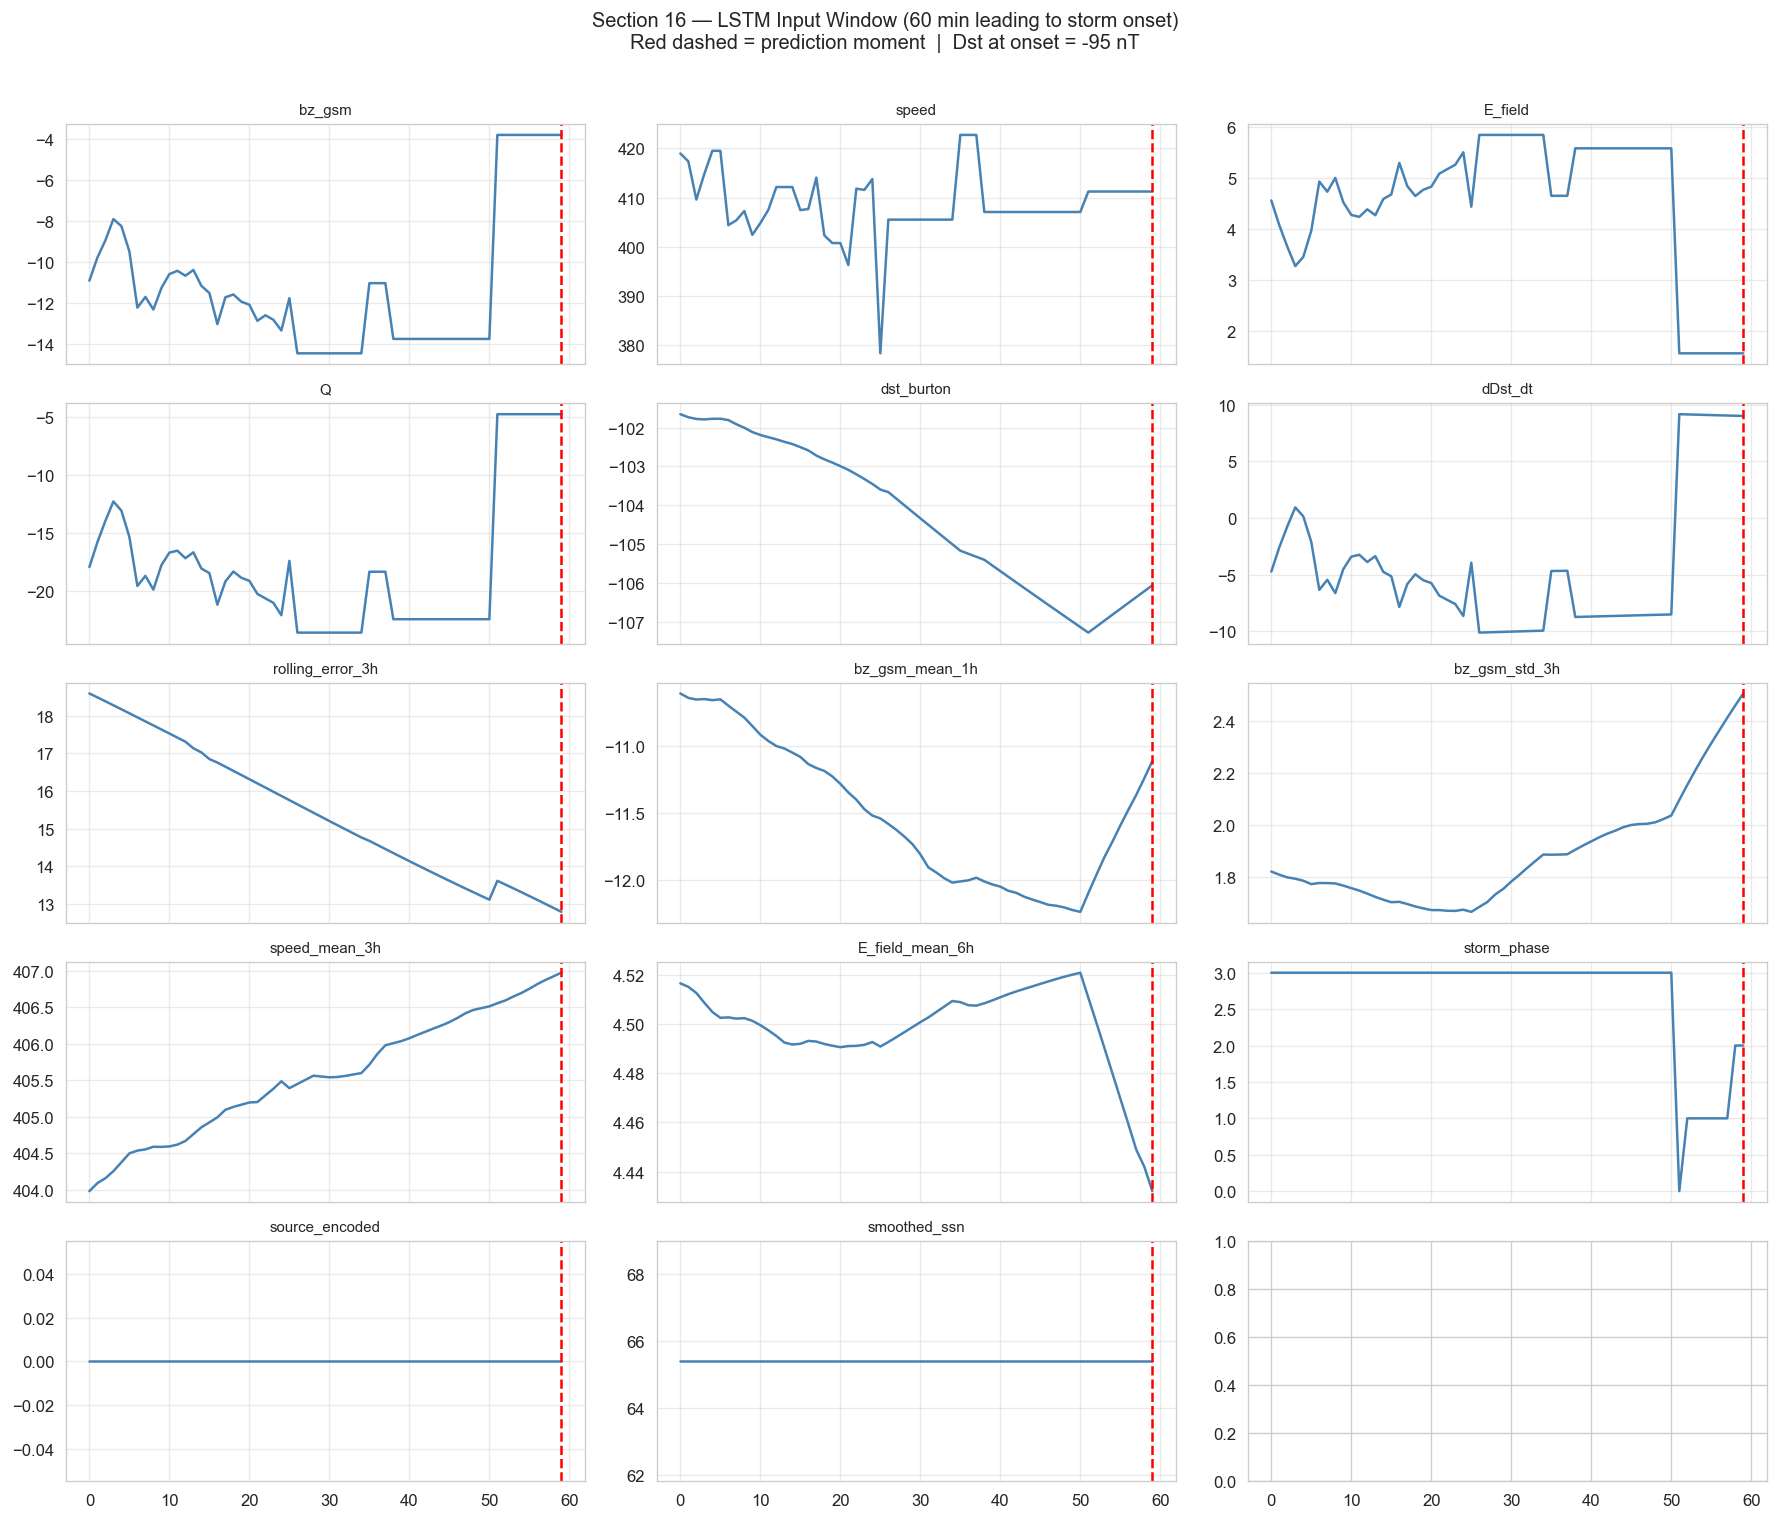

In [29]:

# Find a storm onset in train_a (first hour where Dst < -80 nT)
sub_a    = df[df['period'] == 'train_a'].dropna(subset=['dst']).copy().reset_index(drop=True)
onset_idx = int((sub_a['dst'] < -80).idxmax())
onset_td  = sub_a.iloc[onset_idx]['timedelta']

# Grab the 60-minute window ending at onset from minute-level data
sub_min  = df[df['period'] == 'train_a'].copy().reset_index(drop=True)
end_pos  = int((sub_min['timedelta'] <= onset_td).sum())
start_pos = max(0, end_pos - 60)
window   = sub_min.iloc[start_pos:end_pos].copy()

from models.lstm_corrector import FEATURE_COLS
available_feat = [c for c in FEATURE_COLS if c in window.columns]

print(f'Storm onset timedelta : {onset_td}')
print(f'Dst at onset          : {sub_a.iloc[onset_idx]["dst"]:.0f} nT')
print(f'Window rows           : {len(window)} minutes')
print(f'Features available    : {len(available_feat)}')

ncols = 3
nrows = (len(available_feat) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 2.5), sharex=True)
axes_flat = axes.flat

for ax, feat in zip(axes_flat, available_feat):
    vals = window[feat].values
    ax.plot(vals, lw=1.5, color='steelblue')
    ax.axvline(len(window) - 1, color='red', lw=1.5, linestyle='--')
    ax.set_title(feat, fontsize=9)
    ax.grid(True, alpha=0.4)

for ax in list(axes_flat)[len(available_feat):]:
    ax.set_visible(False)

plt.suptitle(
    f'Section 16 — LSTM Input Window (60 min leading to storm onset)\n'
    f'Red dashed = prediction moment  |  Dst at onset = {sub_a.iloc[onset_idx]["dst"]:.0f} nT',
    y=1.01
)
plt.tight_layout()
plt.savefig('lstm_input_window.png', dpi=150)
plt.show()


## 10. Train/Val Split Strategy

In [ ]:
from sklearn.model_selection import train_test_split

# Hourly rows only (training data)
df_clean = df.dropna(subset=['residual']).copy()
print(f'Total training rows (hourly): {len(df_clean):,}')

# Random 80/20 split
train_df, val_df = train_test_split(df_clean, test_size=0.2, random_state=42)
print(f'Train: {len(train_df):,}  Val: {len(val_df):,}')

# Check storm distribution in train vs val
print('\n=== Storm Distribution in Train vs Val ===')
print(f'{"Category":12s}  {"Train":>10s}  {"Val":>10s}')
for label, lo, hi in [('Quiet',    -30,   10),
                        ('Minor',   -50,  -30),
                        ('Moderate',-100, -50),
                        ('Intense', -200,-100),
                        ('Extreme', -500,-200)]:
    tr = ((train_df['dst'] >= lo) & (train_df['dst'] < hi)).sum()
    va = ((val_df['dst']   >= lo) & (val_df['dst']   < hi)).sum()
    print(f'{label:12s}  {tr:10,}  {va:10,}')

# Compare with period-based split
print('\n=== Period-based Split (old) ===')
train_p = df_clean[df_clean['period'].isin(['train_a', 'train_b'])]
val_p   = df_clean[df_clean['period'] == 'train_c']
print(f'Train: {len(train_p):,}  Val: {len(val_p):,}')
print('\nProblem: different storm intensities per period')
for p in ['train_a', 'train_b', 'train_c']:
    sub = df_clean[df_clean['period'] == p]
    print(f'  {p}: dst_min={sub["dst"].min():.0f} nT  extreme_storms={(sub["dst"]<-100).sum():,}')

print('\nConclusion: Random 80/20 split is better — mixes all storm types in train+val')

## 11. Key Findings Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Burton RMSE varies by period (train_a worst) | Different solar cycles have different predictability |
| 2 | Residual RMSE is highest during main phase | Agent 3 must focus on storm main phase |
| 3 | `dst_burton` has highest correlation with Dst | Physics engine is the strongest feature |
| 4 | 97%+ rows are quiet time | Storm weighting critical to avoid trivial predictions |
| 5 | Period-based split causes distribution shift | Random 80/20 split is better for training |
| 6 | Rolling features track storm buildup | SEQ_LEN=60 captures key dynamics |
| 7 | E_field threshold at 0.49 mV/m is clear | Burton physics correctly identifies injection onset |